[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Using Pretrained LLMs

Our TinyStories model works, and it took about twenty minutes to train.  It also cannot do anything but tell simple stories, because 40,000 children's tales are all it has ever seen.  This notebook contrasts this with a model someone else has spent the effort in training on a VERY large dataset.  More specifically, we use **Qwen3-0.6B**, pretrained on 36 trillion tokens.  Let's see what this gets us!

Before we start let's compare the two models:

| | TinyStories GPT (notebook 3) | Qwen3-0.6B |
|---|---|---|
| parameters | ~4 million | ~600 million  (150×) |
| training tokens | ~5 million | 36 trillion  (7,000,000×) |
| vocabulary | 4,096 | ~151,000 |
| context | 256 tokens | 32,768 tokens |
| architecture | decoder-only transformer | decoder-only transformer |

What is striking is that the two models use essentially the same overall structure in terms of architecture (causal attention), next-token objective, and optimizer family.  The primary difference is scale, which is what moves from a simple story generator and starts being something you can *ask things of*.

Four things to do with it.  First, look inside and confirm it really is the architecture we built.  Second, take **sampling** seriously — the choice of how to turn logits into a token, which we handled with a single `temperature` argument, is a design space with real consequences.  Third, use **in-context learning** to do a task with no training at all — and return to the sentiment problem from the attention module, this time with no gradients whatsoever.  Fourth, compare the **base** model against its **instruct** sibling to see exactly what post-training changes.

A note on downloads and memory: each model is about 1.2 GB.  We load them one at a time and free each before the next, so peak memory stays near 2.5 GB.  Everything below runs on a laptop CPU.

In [ ]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import gc
import math

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

BLUE, GREEN, IO = '#cdddec', '#d0e3d4', '#ededed'
AMBER, TX = '#c0662f', '#333333'

# MPS (Apple GPU) still has kernel gaps that crash the whole process instead of
# raising an error, and this notebook hit one.  CPU is slower but reliable; set
# USE_CPU = False if you want to try the GPU on your machine.
USE_CPU = True

device = ('cpu' if USE_CPU
          else 'cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available() else 'cpu')
torch.manual_seed(0)
print(f'Using {device} device')

# Any base/instruct pair works here -- see the note below on alternatives.
# If this is too slow on your machine, the SmolLM2 pair is ~40% the size:
#     BASE, CHAT = ('HuggingFaceTB/SmolLM2-360M',
#                   'HuggingFaceTB/SmolLM2-360M-Instruct')
# (everything works except the Qwen-specific thinking-mode demo at the end).
BASE = 'Qwen/Qwen3-0.6B-Base'      # pretrained only
CHAT = 'Qwen/Qwen3-0.6B'           # the same model after post-training

def load(name):
    """Load a model in half precision and put it in eval mode."""
    tok = AutoTokenizer.from_pretrained(name)
    model = AutoModelForCausalLM.from_pretrained(
        name, torch_dtype=torch.float32 if device == 'cpu' else torch.bfloat16)
    return tok, model.to(device).eval()

def unload(*objs):
    """Free a model before loading the next one."""
    for o in objs:
        del o
    gc.collect()
    if device == 'cuda':
        torch.cuda.empty_cache()

## Let's peek at the architecture

The following cell loads the base model and looks inside:  The actual module tree and parameter count.

In [2]:
tok, lm = load(BASE)          # ~1.2 GB on first run, then cached

n_params = sum(p.numel() for p in lm.parameters())
cfg = lm.config
print(f'{n_params/1e9:.2f}B parameters | {cfg.num_hidden_layers} layers | '
      f'd_model {cfg.hidden_size} | {cfg.num_attention_heads} query heads / '
      f'{cfg.num_key_value_heads} key-value heads')
print(f'vocabulary {cfg.vocab_size:,} | context {cfg.max_position_embeddings:,} tokens\n')
print(lm)

0.60B parameters | 28 layers | d_model 1024 | 16 query heads / 8 key-value heads
vocabulary 151,936 | context 32,768 tokens

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 1024)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
          (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (up_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (down_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (

Read that module tree against the one we wrote by hand:

* **A stack of identical blocks**, each with self-attention and an MLP wrapped in residual connections — our `GPTBlock`, 28 times over.
* **`input_layernorm` before the attention, `post_attention_layernorm` before the MLP** — pre-norm, exactly the ordering we adopted in notebook 3.
* **`q_proj`, `k_proj`, `v_proj`, `o_proj`** — our `W_q`, `W_k`, `W_v`, `W_o` under different names.
* **A final norm, then `lm_head`** to vocabulary logits — our `ln_f` and output head.

And the differences, every one of them a refinement we previewed at the end of notebook 3 rather than a new idea:

* **`Qwen3RMSNorm`** instead of `LayerNorm`: same normalization without subtracting the mean — cheaper, works as well.
* **No positional-embedding module.** Instead, Qwen3 uses **RoPE**, which injects position by *rotating* the query and key vectors inside attention, so position is encoded relationally rather than added to the input.  This is the single biggest departure from our model, and it is why the context can stretch to 32k.
* **`num_key_value_heads` smaller than `num_attention_heads`** — grouped-query attention: several query heads share one key/value head, which shrinks the KV cache during generation.
* **`MLP` with `gate_proj`, `up_proj`, `down_proj`** — SwiGLU, a gated variant of our two-layer FFN.

That is the whole list.  If you understood notebook 3, you understand this model.

### A note on the choice of model

`Qwen3-0.6B` is not the only reasonable pick, and the notebook is written so you can swap it: change `BASE` and `CHAT` above and most cells work unchanged.  Some comparable options, all decoder-only and all with a genuine **base + instruct pair** (which this notebook needs):

| model | parameters | license friction | notes |
|---|---|---|---|
| **Qwen3-0.6B** | 0.6B | none (Apache 2.0) | what we use; also has the hybrid thinking mode below |
| **SmolLM2-360M** | 0.36B | none (Apache 2.0) | ~40% the size, so roughly 2.5× faster on a CPU |
| **OLMo 2 1B** | 1B | none (Ai2) | training *data* and intermediate checkpoints are published too |
| **Gemma 3 1B** | 1B | accept a license on the Hub | text-only at this size, 32k context |
| **Llama 3.2 1B** | 1B | accept a license on the Hub | widely used, but the gate is a real nuisance |

Three practical criteria drove the choice.  It must be **small enough to run on a CPU**, which rules out the smallest models from several well-known families — Mistral's smallest open-weight model, for instance, is Ministral 3 **3B**, five times larger than what we use here and far too slow for the fine-tuning notebook.  It must be **ungated**, so that nobody spends the first lab accepting licenses and configuring access tokens.  And it must ship **both** a base and an instruct checkpoint, since the whole point of the last section is to compare them.

If your machine struggles, `HuggingFaceTB/SmolLM2-360M` and `HuggingFaceTB/SmolLM2-360M-Instruct` are the drop-in fallback: everything in this notebook works except the thinking-mode demo at the end, which is Qwen-specific.  If you are curious about openness rather than speed, `allenai/OLMo-2-0425-1B` is the one whose training data you can actually inspect.

Before using it, one measurement to connect back to notebook 2 — the same instrument, a much better model.  (This reuses the sliding-window perplexity from that notebook; recall the units caution: both models below are scored on the *identical string*, but each with its **own** tokenizer, so we normalize by words to make the comparison fair.)

In [3]:
SAMPLE_TEXT = (
    "The industrial revolution began in Britain in the late eighteenth century "
    "and transformed manufacturing from hand production to machines. New "
    "textile machinery, steam power, and iron making reshaped cities, labor, "
    "and daily life across Europe, and the changes soon spread to North "
    "America and beyond. Historians still debate why it began where it did, "
    "pointing to coal, colonial trade, property rights, and a culture of "
    "practical tinkering as contributing causes."
)

@torch.no_grad()
def total_nll(model, tokenizer, text):
    """Total negative log-likelihood in nats (text fits in one context here)."""
    ids = tokenizer(text, return_tensors='pt')['input_ids'].to(device)
    logits = model(ids).logits.float()
    logp = logits[0, :-1].log_softmax(-1)
    targets = ids[0, 1:]
    return -logp.gather(-1, targets.unsqueeze(-1)).sum().item(), len(targets)

n_words = len(SAMPLE_TEXT.split())
nll, n_tok = total_nll(lm, tok, SAMPLE_TEXT)
print(f'Qwen3-0.6B-Base : {n_tok:3d} tokens | per-token PPL {math.exp(nll/n_tok):6.2f}'
      f' | per-word PPL {math.exp(nll/n_words):6.2f}')

gpt2_tok = AutoTokenizer.from_pretrained('gpt2')          # cached from notebook 2
gpt2 = AutoModelForCausalLM.from_pretrained('gpt2').to(device).eval()
nll2, n_tok2 = total_nll(gpt2, gpt2_tok, SAMPLE_TEXT)
print(f'GPT-2 (124M)    : {n_tok2:3d} tokens | per-token PPL {math.exp(nll2/n_tok2):6.2f}'
      f' | per-word PPL {math.exp(nll2/n_words):6.2f}')
unload(gpt2)

Qwen3-0.6B-Base :  85 tokens | per-token PPL  19.47 | per-word PPL  36.78
GPT-2 (124M)    :  84 tokens | per-token PPL  41.09 | per-word PPL  86.38


Compare the per-word column: that difference is roughly seven years of scaling.  Note also that the two tokenizers disagree about how many tokens the same string contains — which is precisely why the per-word column, not the per-token one, is the better comparison.

## Sampling: turning logits into text

At each step the model gives a distribution over ~151,000 tokens, must pick one.  In notebook 3 we used temperature and moved on; here we explore this task in more details, because this choice affect output quality more than most people expect.

Start by looking at what a real distribution looks like.

In [4]:
@torch.no_grad()
def next_token_logits(model, tokenizer, prompt):
    ids = tokenizer(prompt, return_tensors='pt')['input_ids'].to(device)
    return model(ids).logits[0, -1].float()

prompt = 'The best thing about living in Colorado is the'
logits = next_token_logits(lm, tok, prompt)
probs = logits.softmax(-1)
top = probs.topk(10)

print(f'{prompt!r}\n')
for p, i in zip(top.values, top.indices):
    print(f'    {tok.decode(i)!r:16s} {p.item():.3f}')

srt = probs.sort(descending=True).values
print(f'\ntokens needed to cover 50% / 90% / 99% of the mass: '
      f'{(srt.cumsum(0) < 0.5).sum().item() + 1} / '
      f'{(srt.cumsum(0) < 0.9).sum().item() + 1} / '
      f'{(srt.cumsum(0) < 0.99).sum().item() + 1}   (of {len(probs):,})')

'The best thing about living in Colorado is the'

    ' variety'       0.050
    ' weather'       0.046
    ' mountains'     0.040
    ' beautiful'     0.027
    ' great'         0.021
    ' fact'          0.018
    ' amazing'       0.016
    ' incredible'    0.015
    ' endless'       0.014
    ' opportunity'   0.013

tokens needed to cover 50% / 90% / 99% of the mass: 38 / 740 / 6035   (of 151,936)


A handful of tokens carry most of the mass, and a very long tail of tens of thousands of tokens carries the rest.  That shape is what every sampling method is trying to exploit: the tail contains the creative options *and* all of the garbage, and the methods differ in where they cut.

* **Greedy** ($\arg\max$): always the top token.  Deterministic, and — as notebook 1 showed — prone to repetition loops.
* **Temperature $T$**: divide the logits by $T$ before the softmax.  $T<1$ sharpens toward greedy, $T>1$ flattens toward uniform.  Note it never removes anything: even at $T=0.5$ the tail keeps a little mass, and over hundreds of tokens "a little" gets sampled eventually.
* **Top-$k$**: keep the $k$ most likely tokens, renormalize, sample.  Simple, but $k$ is fixed while the *sharpness* of the distribution is not: when the model is certain, $k=50$ reaches deep into nonsense; when it is genuinely uncertain, $k=50$ may cut off good options.
* **Top-$p$ (nucleus)**: keep the smallest set of tokens whose probability sums to $p$, then sample.  The candidate set now *adapts* — one token when the model is confident, hundreds when it is not.  This is the default in most deployed systems (Holtzman et al., 2020).

All four are a few lines each, applied to the logits before sampling.

In [5]:
def apply_temperature(logits, T):
    return logits / max(T, 1e-6)

def top_k_filter(logits, k):
    """Keep the k highest-scoring tokens; -inf everything else."""
    if k is None or k >= logits.numel():
        return logits
    kth = logits.topk(k).values[-1]
    return logits.masked_fill(logits < kth, float('-inf'))

def top_p_filter(logits, p):
    """Keep the smallest set of tokens whose probability mass reaches p."""
    if p is None or p >= 1.0:
        return logits
    srt, idx = logits.sort(descending=True)
    cum = srt.softmax(-1).cumsum(-1)
    drop = cum - srt.softmax(-1) >= p      # everything past the nucleus
    drop[0] = False                        # always keep the top token
    out = logits.clone()
    out[idx[drop]] = float('-inf')
    return out

# how many tokens survive each rule, on the distribution we just inspected?
for name, filt in [('top-k = 5', lambda l: top_k_filter(l, 5)),
                   ('top-k = 50', lambda l: top_k_filter(l, 50)),
                   ('top-p = 0.9', lambda l: top_p_filter(l, 0.9)),
                   ('top-p = 0.95', lambda l: top_p_filter(l, 0.95))]:
    kept = torch.isfinite(filt(logits)).sum().item()
    print(f'{name:14s} keeps {kept:5d} tokens')

top-k = 5      keeps     5 tokens
top-k = 50     keeps    50 tokens
top-p = 0.9    keeps   740 tokens
top-p = 0.95   keeps  1653 tokens


The adaptivity of top-$p$ is easiest to see by comparing two prompts — one where the continuation is nearly forced, one where it is wide open.

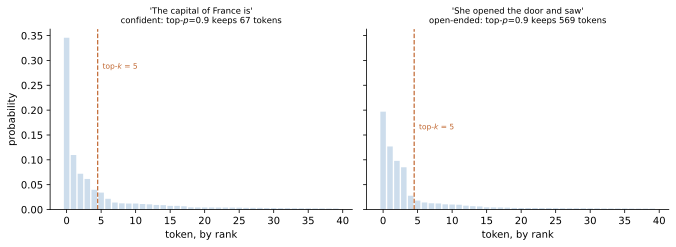

In [6]:
pairs = [('The capital of France is', 'confident'),
         ('She opened the door and saw', 'open-ended')]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), sharey=True)
for ax, (pr, kind) in zip(axes, pairs):
    lg = next_token_logits(lm, tok, pr)
    pb = lg.softmax(-1).sort(descending=True).values[:40].cpu().numpy()
    n_p = torch.isfinite(top_p_filter(lg, 0.9)).sum().item()

    ax.bar(range(40), pb, color=[BLUE if i < n_p else IO for i in range(40)])
    ax.axvline(4.5, color=AMBER, ls='--', lw=1.2)
    ax.text(5.2, pb.max() * 0.82, 'top-$k$ = 5', fontsize=7.5, color=AMBER)
    ax.set_title(f'{pr!r}\n{kind}: top-$p$=0.9 keeps {n_p} tokens', fontsize=8.5)
    ax.set_xlabel('token, by rank')
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('probability')
plt.tight_layout();

Blue bars are the tokens that top-$p$ = 0.9 keeps; the dashed line is where a fixed top-$k$ = 5 cuts no matter what.  The comparison to make is between the panels: the nucleus width *changes* with the model's certainty, while $k$ never does.  Whenever the nucleus is narrower than $k$, the fixed rule is letting implausible tokens through; whenever it is wider, the fixed rule is discarding continuations the model considered reasonable.  Neither error is available to top-$p$, which is the argument for it in one sentence.  (Check the printed counts above against the panel titles — and note that a prompt's *apparent* certainty to you is not always the model's.)

Now generate with each, from an identical prompt and seed.

In [ ]:
@torch.no_grad()
def generate(model, tokenizer, prompt, max_new_tokens=60, temperature=1.0,
             top_k=None, top_p=None, greedy=False, seed=0):
    """The autoregressive loop from notebook 1, with a selection rule."""
    rng_state = torch.get_rng_state()
    torch.manual_seed(seed)
    ids = tokenizer(prompt, return_tensors='pt')['input_ids'].to(device)
    for _ in range(max_new_tokens):
        # Only the last position is ever used, and with a 151k vocabulary the
        # full logits tensor dominates the cost of a step -- ask for one row
        # where the installed transformers supports it.
        try:
            out = model(ids, logits_to_keep=1)
        except TypeError:
            out = model(ids)
        lg = out.logits[0, -1].float()
        if greedy:
            nxt = lg.argmax().view(1, 1)
        else:
            lg = top_p_filter(top_k_filter(apply_temperature(lg, temperature),
                                           top_k), top_p)
            nxt = torch.multinomial(lg.softmax(-1), 1).view(1, 1)
        ids = torch.cat([ids, nxt], dim=1)
        if nxt.item() == tokenizer.eos_token_id:
            break
    torch.set_rng_state(rng_state)
    return tokenizer.decode(ids[0], skip_special_tokens=True)

PROMPT = 'The three most useful things to know about machine learning are'
settings = [('greedy',            dict(greedy=True)),
            ('T = 0.3',           dict(temperature=0.3)),
            ('T = 1.0 (raw)',     dict(temperature=1.0)),
            ('T = 1.5',           dict(temperature=1.5)),
            ('top-k = 50',        dict(top_k=50)),
            ('top-p = 0.9',       dict(top_p=0.9)),
            ('top-p 0.9, T 0.8',  dict(top_p=0.9, temperature=0.8))]

for name, kw in settings:
    print(f'--- {name} ---')
    print(generate(lm, tok, PROMPT, **kw), '\n')

Read these against each other rather than individually.  Greedy and low temperature are safe and dull, and greedy will usually start repeating itself if you extend `max_new_tokens`.  Raw sampling at $T = 1.5$ visibly derails — that is the tail being sampled.  Top-$p$ = 0.9 with a mild temperature is what most production systems ship, and it should read as the best compromise here too.

Notice what none of these is: *correct*.  A base model completes text plausibly; plausibility is not accuracy, and no sampling rule fixes that.

## In-context learning

Now the capability that scale bought, and the one that has no analogue in our TinyStories model: **doing a task described in the prompt, with no parameter updates**.

We return to IMDb sentiment — the task from the attention module, where we trained a transformer from scratch (~0.83 accuracy), then used frozen BERT features (~0.83), then fine-tuned BERT (~0.89–0.92).  All three needed labeled data and gradient descent.  Here we do it with a prompt.

The mechanics matter.  Rather than *generating* a word and parsing it, we ask the model for one forward pass and compare the probabilities it assigns to the two label tokens — this is exercise 1 of notebook 1, made concrete.  It is faster, and it removes all parsing ambiguity: the model's answer is whichever label token scores higher.

In [8]:
import os, tarfile, urllib.request

def download_imdb(data_dir='../data'):
    url = 'https://d2l-data.s3-accelerate.amazonaws.com/aclImdb_v1.tar.gz'
    os.makedirs(data_dir, exist_ok=True)
    archive = os.path.join(data_dir, 'aclImdb_v1.tar.gz')
    if not os.path.exists(archive):
        print('downloading', url, '...'); urllib.request.urlretrieve(url, archive)
    extracted = os.path.join(data_dir, 'aclImdb')
    if not os.path.exists(extracted):
        with tarfile.open(archive) as tar:
            tar.extractall(data_dir)
    return extracted

def read_imdb(data_dir, is_train, n=None, seed=0):
    texts, labels = [], []
    for label in ('pos', 'neg'):
        folder = os.path.join(data_dir, 'train' if is_train else 'test', label)
        for f in os.listdir(folder):
            with open(os.path.join(folder, f), 'rb') as fh:
                texts.append(fh.read().decode('utf-8').replace('<br />', ' '))
            labels.append(1 if label == 'pos' else 0)
    if n is not None:
        idx = np.random.default_rng(seed).permutation(len(texts))[:n]
        texts, labels = [texts[i] for i in idx], [labels[i] for i in idx]
    return texts, labels

data_dir = download_imdb()
test_texts, test_labels = read_imdb(data_dir, is_train=False, n=100, seed=0)
demo_texts, demo_labels = read_imdb(data_dir, is_train=True, n=8, seed=1)
print(f'{len(test_texts)} test reviews, {sum(test_labels)} positive')

downloading https://d2l-data.s3-accelerate.amazonaws.com/aclImdb_v1.tar.gz ...
100 test reviews, 48 positive


In [9]:
def truncate(text, words=60):
    return ' '.join(text.split()[:words])

def build_prompt(review, shots=()):
    """A few-shot prompt: worked examples, then the query, cut off mid-answer."""
    parts = []
    for t, y in shots:
        parts.append(f'Review: {truncate(t)}\nSentiment: '
                     f'{"positive" if y == 1 else "negative"}')
    parts.append(f'Review: {truncate(review)}\nSentiment:')
    return '\n\n'.join(parts)

# the two candidate answers, as single tokens (note the leading space)
POS_ID = tok(' positive')['input_ids'][0]
NEG_ID = tok(' negative')['input_ids'][0]
print(f'label tokens: {tok.decode(POS_ID)!r} -> {POS_ID}, '
      f'{tok.decode(NEG_ID)!r} -> {NEG_ID}')

@torch.no_grad()
def classify(model, tokenizer, review, shots=()):
    """One forward pass; the prediction is the higher-scoring label token."""
    lg = next_token_logits(model, tokenizer, build_prompt(review, shots))
    return int(lg[POS_ID] > lg[NEG_ID])

print('\nexample prompt (1 shot):\n')
print(build_prompt(test_texts[0], shots=list(zip(demo_texts, demo_labels))[:1])[:700])

label tokens: ' positive' -> 6785, ' negative' -> 8225

example prompt (1 shot):

Review: I suppose all the inside jokes is what made Munchies a cult classic. I thought it was awful, though given the ridiculous story and the nature of the characters, it probably could've been a much better (and funnier) movie. Maybe all they needed was a real budget. Munchies, as many viewers have pointed out already, is something of a Gremlins
Sentiment: negative

Review: This film is terrible. Not only is the story unbelievable, the situations the characters put themselves in are so silly, to the point where it isn't shocking. I find it sad that Daisy Eagan, star of Broadway's The Secret Garden, decided that this would be a career step. The idea is interesting, two young girls coming of


In [10]:
def accuracy(model, tokenizer, n_shots, texts, labels):
    shots = list(zip(demo_texts, demo_labels))[:n_shots]
    preds = [classify(model, tokenizer, t, shots) for t in texts]
    return sum(int(p == y) for p, y in zip(preds, labels)) / len(labels)

shot_counts = [0, 1, 2, 4, 8]
base_acc = []
for k in shot_counts:                      # a couple of minutes on CPU
    a = accuracy(lm, tok, k, test_texts, test_labels)
    base_acc.append(a)
    print(f'{k}-shot: accuracy {a:.2f}')

0-shot: accuracy 0.77
1-shot: accuracy 0.82
2-shot: accuracy 0.77
4-shot: accuracy 0.78
8-shot: accuracy 0.82


In [ ]:
fig, ax = plt.subplots(figsize=(6.2, 3.9))
ax.plot(shot_counts, base_acc, 'o-', color='#3d6ea8', label='Qwen3-0.6B-Base, in-context')
ax.axhline(0.5, ls=':', color='0.6')
ax.text(0.1, 0.505, 'chance', fontsize=7.5, color='0.45')
for y, lbl, col in [(0.83, 'from-scratch transformer (attention module)', AMBER),
                    (0.90, 'fine-tuned DistilBERT (attention module)', AMBER),
                    (0.91, 'TF-IDF + logistic regression (attention module)', '#7a7a7a')]:
    ax.axhline(y, ls='--', color=col, lw=1)
    ax.text(8, y - 0.018, lbl, fontsize=7.2, color=col, ha='right', va='top')
ax.set_xlabel('examples in the prompt'); ax.set_ylabel('test accuracy')
ax.set_ylim(0.4, 1.0)
ax.set_title('Sentiment with no gradient steps at all', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout();

Pause on what the dashed lines mean — and read the top one first, because it is the uncomfortable one.

The two amber lines cost us, in the attention module, a labeled training set and a training loop apiece.  The blue curve costs a prompt: a 0.6B model, small enough to run on your laptop and *not* fine-tuned for sentiment or anything else, lands in the same neighborhood by reading a handful of examples inside a single forward pass.  That is in-context learning, and it is the practical reason the field reorganized itself around large pretrained models: one model, many tasks, no task-specific training.

Now the grey line.  **TF-IDF with logistic regression — word counts and a linear classifier — reaches about 0.91 on this task**, above everything else on the plot.  The attention module's NLI notebook opened with exactly this point: IMDb sentiment is a *lexical* task, where the answer is mostly in which words appear, so counting the right words is nearly enough and the fancy machinery is overkill.  Whatever the LLM is doing here, it is not beating a bag of words.

Both readings are true and neither should be dropped.  In-context learning is remarkable as a *mechanism* — no gradients, one model, task specified in English — and unremarkable as a *result* on a task this easy.  The honest test of whether a general model can replace a specialized one has to be run on a task where bag-of-words fails, which is precisely what the attention module's NLI ladder provides and what the assignment notebook (notebook 6) takes up.

Two caveats keep the mechanism claim honest.  Accuracy typically climbs steeply from zero to a few shots and then flattens — more examples stop helping well before the context fills up.  And in-context learning is *sensitive*: the label words you pick, the order of the examples, even the formatting can move accuracy by several points, which is why "prompt engineering" is an empirical activity rather than a mystical one (exercise 5).

In [12]:
QUESTION = 'What is the capital of Colorado?'
print('--- BASE model, question asked directly ---')
print(generate(lm, tok, QUESTION, max_new_tokens=60, top_p=0.9, temperature=0.8))
unload(lm)      # free the base model before loading its instruct sibling

--- BASE model, question asked directly ---
What is the capital of Colorado? The capital of Colorado is Denver.


Typically the base model answers and then keeps going — more questions, a quiz, a list, whatever document its training data suggests should follow.  It is not being unhelpful; it is doing its job exactly as trained.  *Continuing a document* and *answering a person* are different objectives, and only the first one was ever optimized.

The instruct model is the same architecture and the same pretraining, followed by supervised fine-tuning on instruction–response pairs and preference tuning (notebook 1's stages 2 and 3).  Before we use it, look at what a "chat" actually is at the token level: a **chat template** flattens a list of role-tagged messages into one string with special delimiters.  There is no separate chat mechanism — the model is still just continuing text.

In [13]:
chat_tok, chat_lm = load(CHAT)

messages = [{'role': 'user', 'content': QUESTION}]
templated = chat_tok.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)
print('what the model actually receives:\n')
print(repr(templated))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

what the model actually receives:

'<|im_start|>user\nWhat is the capital of Colorado?<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\n'


In [14]:
@torch.no_grad()
def chat(prompt, max_new_tokens=120, thinking=False, **kw):
    # `enable_thinking` is a Qwen3 chat-template option; other model families
    # ignore it or do not define it.
    text = chat_tok.apply_chat_template(
        [{'role': 'user', 'content': prompt}], tokenize=False,
        add_generation_prompt=True, enable_thinking=thinking)
    out = generate(chat_lm, chat_tok, text, max_new_tokens=max_new_tokens, **kw)
    return out[len(text):].strip()        # keep only the newly generated part

print('--- INSTRUCT model, same question ---')
print(chat(QUESTION, top_p=0.9, temperature=0.7))

for q in ['Explain perplexity in two sentences.',
          'Write a haiku about gradient descent.']:
    print(f'\n--- {q} ---')
    print(chat(q, top_p=0.9, temperature=0.7))

--- INSTRUCT model, same question ---
r**.

--- Explain perplexity in two sentences. ---
l a model's predictions are making sense, indicating how much uncertainty is present in the model's outputs. A high perplexity suggests that the model is not learning well from the data, while a low perplexity indicates that the model is performing well and making sense of the input.

--- Write a haiku about gradient descent. ---
t,  
A descent finds its way with light.  
The data turns, it walks.


Same weights-shaped object, same pretraining, entirely different behavior: it answers the question, stops when done, and follows the format it was asked for.  Nothing about the *architecture* changed — only what the model was trained to consider a good continuation.  This is the clearest available demonstration that "assistant" is a behavior installed by post-training, not a property of transformers.

One more feature worth seeing, because it makes notebook 1's chain-of-thought discussion concrete.  Qwen3 is a **hybrid reasoning** model: with thinking enabled, it first generates a `<think>` block of intermediate reasoning, then its answer.  Those tokens are ordinary generated tokens — the same loop, no new machinery — and they work for the reason notebook 1 gave: the model conditions its answer on reasoning it has already written.

In [15]:
PUZZLE = ('A bat and a ball cost $1.10 in total. The bat costs $1.00 more '
          'than the ball. How much does the ball cost?')

print('--- thinking OFF ---')
print(chat(PUZZLE, max_new_tokens=120, thinking=False, top_p=0.9, temperature=0.7))

print('\n--- thinking ON (the <think> block is generated, then the answer) ---')
print(chat(PUZZLE, max_new_tokens=600, thinking=True, top_p=0.95, temperature=0.6))

--- thinking OFF ---
t:
- $ x $ be the cost of the ball.
- $ y $ be the cost of the bat.

We are told:
1. The total cost is $1.10:  
   $ x + y = 1.10 $

2. The bat costs $1.00 more than the ball:  
   $ y = x + 1.00 $

Now substitute the second equation into the first:

$$
x + (x + 1.00) = 1.10
$$

--- thinking ON (the <think> block is generated, then the answer) ---
problem here where a bat and a ball cost $1.10 in total. Also, the bat costs $1.00 more than the ball. I need to find out how much the ball costs. Hmm, let me think.

First, let me note down the information given:

- Total cost of bat + ball = $1.10
- Cost of bat = cost of ball + $1.00

So, let me assign variables to make this easier. Let me call the cost of the ball 'x'. Then, since the bat is $1.00 more expensive, the cost of the bat would be x + 1.00.

So, according to the total cost, the sum of the ball's cost and the bat's cost equals $1.10. That would be:

x + (x + 1.00) = 1.10

Let me write that equation again:

x 

The correct answer to this puzzle is 0.05.  Watch whether the thinking block gets there — at 0.6B it may not.  Reasoning traces improve accuracy but do not manufacture capability.  Larger reasoning models are the same mechanism with more of everything.

We have now traced the entire arc: a next-token objective (notebook 1), an instrument to measure it (notebook 2), a model built and trained from scratch (notebook 3), and a pretrained model used the way LLMs are actually used (this one).  One question remains — what if the behavior you want is not in the model already?  That is fine-tuning, and the final notebook does it cheaply with LoRA.

## Summary

* **Qwen3-0.6B is our notebook-3 architecture**, scaled and refined: pre-norm blocks, causal attention, tied-vocabulary output — with RMSNorm, **RoPE** (position by rotating Q and K, no positional-embedding module at all), grouped-query attention, and a SwiGLU MLP.  No new ideas, only better versions of ours.
* **Sampling is a real design choice.**  Greedy repeats; temperature rescales without ever pruning; top-$k$ cuts at a fixed rank regardless of certainty; **top-$p$** adapts its candidate set to the distribution's shape, which is why it is the deployed default.
* **In-context learning** performs a task from examples in the prompt with no gradient steps — reaching, on IMDb sentiment, roughly what a *trained* transformer achieved in the attention module.  It saturates after a few examples and is sensitive to wording, ordering, and format.
* **Base vs. instruct** isolates post-training exactly: same architecture and pretraining, but SFT + preference tuning turn a document-continuer into an assistant.  A **chat template** is just a string format — there is no separate chat mechanism.
* **Reasoning traces** (`<think>` blocks) are ordinary generated tokens that the final answer is conditioned on.

## Exercises

1. **Where does top-$p$ beat top-$k$?**  Find a prompt where top-$k$=5 and top-$p$=0.9 keep very different numbers of tokens, in *both* directions (one prompt where $k$ is far too permissive, one where it is far too restrictive).  Generate from each and describe how the outputs differ.  Then explain why temperature alone can never do what top-$p$ does.

2. **Greedy loops.**  Generate 300 greedy tokens and find a repetition loop.  Explain in terms of the conditional distribution why a loop, once entered, is self-sustaining — and why sampling escapes it.  Does a low temperature (say 0.2) escape it?  Why or why not?

3. **The tail is bigger than it looks.**  For a fixed prompt, compute how much total probability mass sits outside the top 100 tokens.  If that mass is only 2%, roughly how many tokens would you expect to be drawn from it over a 500-token generation at $T=1$?  Relate your answer to why raw sampling degrades over long outputs.

4. **A better classifier prompt.**  Our prompt uses `Review: ... \nSentiment:` with label words " positive"/" negative".  Try (a) different label words (" good"/" bad", " yes"/" no" with a rephrased question), (b) an instruction line before the examples, and (c) reversed example order.  Report accuracy for each.  How large is the spread, and what does that imply about reporting a single prompt's accuracy as *the* model's accuracy?

5. **Class balance in the shots.**  Rerun the shot sweep with all-positive demonstrations.  Does accuracy collapse toward predicting "positive"?  What does that tell you about what the model infers from demonstrations — the task, or the label distribution?

6. **Base vs. instruct, measured.**  Run the in-context sentiment evaluation on the *instruct* model with the same prompts.  Is it better?  Post-training optimizes for helpfulness, not for next-token prediction on arbitrary formats — predict the direction before you run it, then explain the result.

7. **Perplexity after post-training.**  Compute `total_nll` for both the base and instruct models on `SAMPLE_TEXT`.  Notebook 2 claimed instruct models often have *worse* perplexity on plain text.  Do you observe that here, and why would it be expected rather than alarming?

8. **What does RoPE buy?**  Our notebook-3 model used sinusoidal encodings added to the input and capped at 256 positions.  Read the `Qwen3Attention` source (`lm.model.layers[0].self_attn.__class__`) and find where `position_embeddings` enter the computation.  Explain why rotating Q and K encodes *relative* position, and why that extrapolates to longer contexts better than an added absolute signal.